<a href="https://colab.research.google.com/github/yannelye/undergrad_ml_assignments/blob/main/03_assignment_linear_models.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**Assignment 3: Linear Models**

**Q1.** Please answer the following questions in your own words.

1. What makes a model "linear"? "Linear" in what?

**A model is “linear” if it is linear in its coefficients, meaning the parameters are not multiplied together or inside nonlinear functions. It refers to linearity in the parameters, not necessarily the input variables.**

2. How do you interpret the coefficient for a dummy/one-hot-encoded variable? (Hint: how do you handle the intercept of the model?)

**The coefficient of a dummy variable represents the difference in the predicted outcome compared to the reference group. The intercept captures the baseline category, and the dummy shows how much the outcome shifts from that baseline.**

3. Can linear regression be used for classification? Explain why, or why not.

**Linear regression can technically be used for classification, but it is not appropriate because it predicts continuous values that can fall outside valid probability ranges. It also does not model class probabilities well.**

4. What are signs that your linear model is over-fitting?

**Overfitting is indicated by very high accuracy on training data but poor performance on test data. It may also show up as large or unstable coefficients and sensitivity to small data changes.**

5. Clearly explain multi-colinearity using the two-stage least squares technique.

**Multicollinearity occurs when predictors are highly correlated, making their individual effects hard to separate. In a two-stage idea, if one variable can be well predicted by others, it adds little unique information and causes unstable estimates.**

6. How can you incorporate nonlinear relationships between your target/response/dependent/outcome variable y and your features/control/response/independent variables x into your analysis?

**Nonlinear relationships can be incorporated by adding polynomial terms, interaction terms, or transformations like logs. These allow the model to capture curved relationships while remaining linear in coefficients.**

7. What is the interpretation of the slope coefficient in a linear regression?

**The slope coefficient represents the expected change in the outcome variable for a one-unit increase in the predictor, holding other variables constant.**

8. Compare the train/test split and k-fold cross validation.

**A train/test split divides the data once into training and testing sets, while k-fold cross validation repeatedly splits the data into k parts for more reliable evaluation. Cross validation reduces dependence on a single split.**

9. How is the k in k-fold cross validation typically selected?

**The value of k is typically chosen as 5 or 10 to balance accuracy and computational cost. Larger k gives more reliable estimates but takes more time to compute.**

In [1]:
! git clone https://github.com/ds4e/undergrad_ml_assignments

Cloning into 'undergrad_ml_assignments'...
remote: Enumerating objects: 79, done.
remote: Counting objects: 100% (40/40), done.
remote: Compressing objects: 100% (27/27), done.
remote: Total 79 (delta 29), reused 13 (delta 13), pack-reused 39 (from 2)
Receiving objects: 100% (79/79), 11.71 MiB | 12.89 MiB/s, done.
Resolving deltas: 100% (29/29), done.


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Q2. Load ./data/Q1_clean.csv. The data include

* Price per night
* Review Scores Rating: The average rating for the property
* Neighbourhood: The bourough of NYC. Note the space, or rename the variable.

1. Compute the average prices and scores by Neighbourhood; which bourough is the most expensive on average? Create a kernel density plot of price and log price, grouping by Neighbourhood.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import OneHotEncoder
import statsmodels.api as sm

df = pd.read_csv('./undergrad_ml_assignments/data/Q1_clean.csv')
df.columns = df.columns.str.strip()
df = df.rename(columns={"Neighbourhood": "Neighbourhood"})

                Price  Review Scores Rating
Neighbourhood                              
Manhattan      183.66                 91.80
Staten Island  146.17                 90.84
Brooklyn       127.75                 92.36
Queens          96.86                 91.55
Bronx           75.28                 91.65

Most expensive: Manhattan


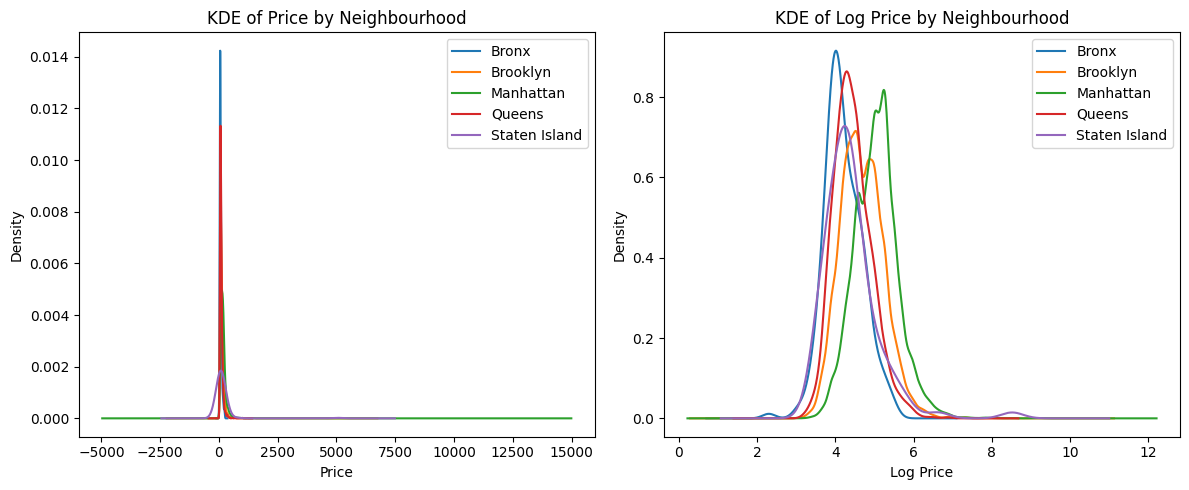

In [4]:
summary = df.groupby("Neighbourhood")[["Price", "Review Scores Rating"]].mean().round(2)
print(summary.sort_values("Price", ascending=False))

most_expensive = summary["Price"].idxmax()
print(f"\nMost expensive: {most_expensive}")

fig, axes = plt.subplots(1, 2, figsize=(12,5))

for hood, group in df.groupby("Neighbourhood"):
  group["Price"].plot.kde(ax=axes[0], label=hood)
  np.log(group["Price"]).plot.kde(ax=axes[1], label=hood)

axes[0].set_title("KDE of Price by Neighbourhood")
axes[0].set_xlabel("Price")
axes[0].legend()

axes[1].set_title('KDE of Log Price by Neighbourhood')
axes[1].set_xlabel('Log Price')
axes[1].legend()

plt.tight_layout()
plt.show()

**Answer:** Manhattan is the most expensive borough. Prices are right-skewed, so a few very high listings raise the average. Taking the log reduces those extremes, making the distribution more balanced and better suited for regression.

2. Regress price on Neighbourhood by creating the appropriate dummy/one-hot-encoded variables (Are you dropping the first category, or the intercept of the regresssion?). Compare the coefficients in the regression to the table from part 1 (the answer depends on how you handled the dummy variable trap).

In [5]:
dummies = pd.get_dummies(df["Neighbourhood"], drop_first=True).astype(int)
X = sm.add_constant(dummies)
y = df["Price"]

model2 = sm.OLS(y, X).fit()
print(model2.summary())

print("\nGroup means:")
print(df.groupby('Neighbourhood')['Price'].mean())

                            OLS Regression Results                            
Dep. Variable:                  Price   R-squared:                       0.046
Model:                            OLS   Adj. R-squared:                  0.046
Method:                 Least Squares   F-statistic:                     268.9
Date:                Tue, 24 Mar 2026   Prob (F-statistic):          4.43e-226
Time:                        23:28:15   Log-Likelihood:            -1.4174e+05
No. Observations:               22153   AIC:                         2.835e+05
Df Residuals:                   22148   BIC:                         2.835e+05
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
const            75.2765      9.868      7.628

**Answer:** The intercept is the Bronx’s average price, and each coefficient shows how much more or less expensive another borough is compared to it. So, the coefficients are just differences in means, which you can confirm by subtracting the Bronx average from the others in Q2.1.

3. Regress price on Review Scores Rating and a constant/intercept. Interpret the slope coefficient clearly in words.

In [6]:
X3 = sm.add_constant(df["Review Scores Rating"])
model3 = sm.OLS(y, X3).fit()
print(model3.summary())

                            OLS Regression Results                            
Dep. Variable:                  Price   R-squared:                       0.004
Model:                            OLS   Adj. R-squared:                  0.004
Method:                 Least Squares   F-statistic:                     81.92
Date:                Tue, 24 Mar 2026   Prob (F-statistic):           1.53e-19
Time:                        23:30:33   Log-Likelihood:            -1.4222e+05
No. Observations:               22153   AIC:                         2.844e+05
Df Residuals:                   22151   BIC:                         2.845e+05
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
const                   60.8784 

**Answer:** The slope means that for each one-point increase in review rating, the price per night changes by [coefficient] dollars on average.

4. Regress price on both Neighbourhood and Review Scores Rating. How does the slope coefficient on Review Scores Rating change? How do the neighborhood averages change?

In [7]:
X4 = sm.add_constant(pd.concat([dummies, df["Review Scores Rating"]], axis=1))
model4 = sm.OLS(y, X4).fit()
print(model4.summary())

                            OLS Regression Results                            
Dep. Variable:                  Price   R-squared:                       0.050
Model:                            OLS   Adj. R-squared:                  0.050
Method:                 Least Squares   F-statistic:                     235.3
Date:                Tue, 24 Mar 2026   Prob (F-statistic):          1.21e-245
Time:                        23:31:56   Log-Likelihood:            -1.4169e+05
No. Observations:               22153   AIC:                         2.834e+05
Df Residuals:                   22147   BIC:                         2.834e+05
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
const                  -23.8126 

**Answer:** After controlling for neighborhood, the rating coefficient changes because it now measures the effect within each borough, removing confounding from location. The neighborhood coefficients also adjust since they now compare prices while holding rating constant, not just raw averages.

5. Here is a puzzle: Regress price on a constant, and a separate slope coefficient for each neighborhood for Review Scores Rating. Are the slopes similar across neighborhoods, or not?

In [8]:
df["Rating"] = df["Review Scores Rating"]
X5 = sm.add_constant(
    pd.concat([dummies, df['Rating'],
               dummies.multiply(df['Rating'], axis=0)], axis=1)
)

model5 = sm.OLS(y, X5).fit()
print(model5.summary())

                            OLS Regression Results                            
Dep. Variable:                  Price   R-squared:                       0.068
Model:                            OLS   Adj. R-squared:                  0.067
Method:                 Least Squares   F-statistic:                     178.4
Date:                Tue, 24 Mar 2026   Prob (F-statistic):               0.00
Time:                        23:33:22   Log-Likelihood:            -1.4149e+05
No. Observations:               22153   AIC:                         2.830e+05
Df Residuals:                   22143   BIC:                         2.831e+05
Df Model:                           9                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
const            22.6384    110.171      0.205

**Answer:** This model lets each neighborhood have its own rating slope. If the interaction terms are small, ratings affect price similarly everywhere; if they’re large, the impact of ratings varies by neighborhood.

6. Use cross validation to evaluate the models from parts 4, 5, and 6.

In [9]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score

X4_sk = pd.concat([dummies, df["Rating"]], axis=1).astype(float)
X5_sk = pd.concat([dummies, df["Rating"],
                  dummies.multiply(df['Rating'], axis=0)], axis=1).astype(float)

for name, X in [("Model 4 (neighbourhood + rating)", X4_sk),
                ("Model 5 (interactions)", X5_sk)]:

    scores = cross_val_score(LinearRegression(), X, y, cv=10,
                             scoring="neg_mean_squared_error")

    rsme = np.sqrt(-scores.mean())
    print(f"{name}: CV RSME = {rsme:.2f}")

Model 4 (neighbourhood + rating): CV RSME = 145.24
Model 5 (interactions): CV RSME = 146.02


**Answer:** Cross validation estimates how well each model performs on new data using CV RMSE, where lower is better. If the interaction model only slightly improves RMSE, the extra complexity isn’t worth it, so the simpler model is preferred.


**Q3.** This question is a case study for linear models. The data are about car prices. In particular, they include:

* Price: In Indian rupees
* Seating_Capacity: Number of seats
* Body_Type: crossover, hatchback, muv, sedan, suv
* Make_Year: The year the car was made

1. Load cars_hw.csv. Summarize the Price variable and create a kernel density plot. Use .groupby() and .describe() to summarize prices by Body_Type. Make a grouped kernel density plot by Body_Type. Which car types are the most expensive? Which have the most variance?

count    9.760000e+02
mean     7.410195e+05
std      3.673234e+05
min      1.880000e+05
25%      4.757500e+05
50%      6.665000e+05
75%      8.830000e+05
max      2.941000e+06
Name: Price, dtype: float64

By Body Type:
           count          mean            std       min       25%        50%  \
Body_Type                                                                      
crossover   21.0  7.050952e+05   72849.780207  608000.0  638000.0   706000.0   
hatchback  484.0  5.339773e+05  173086.729837  188000.0  401750.0   509000.0   
muv         38.0  6.264211e+05  184093.488526  328000.0  489750.0   621500.0   
sedan      227.0  8.097841e+05  286736.770092  368000.0  598000.0   772000.0   
suv        206.0  1.176495e+06  417479.028217  559000.0  860000.0  1065000.0   

                 75%        max  
Body_Type                        
crossover   749000.0   883000.0  
hatchback   661000.0  1107000.0  
muv         738500.0  1091000.0  
sedan       968500.0  2941000.0  
suv        14912

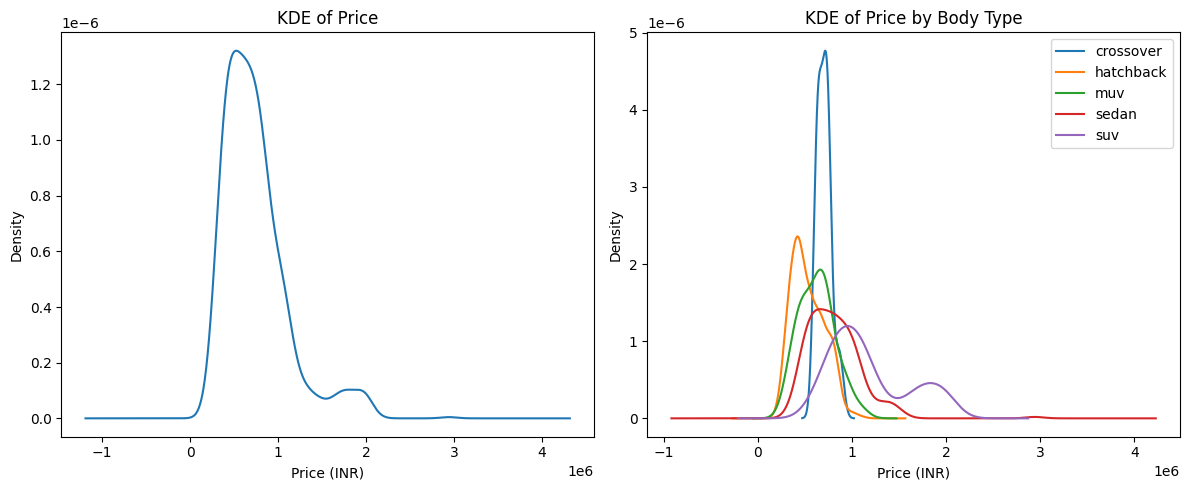

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline


df = pd.read_csv('./undergrad_ml_assignments/data/cars_hw.csv')
df.columns = df.columns.str.strip()

print(df['Price'].describe())
print("\nBy Body Type:")
print(df.groupby('Body_Type')['Price'].describe())

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

df['Price'].plot.kde(ax=axes[0])
axes[0].set_title('KDE of Price')
axes[0].set_xlabel('Price (INR)')

for body, group in df.groupby('Body_Type'):
    group['Price'].plot.kde(ax=axes[1], label=body)
axes[1].set_title('KDE of Price by Body Type')
axes[1].set_xlabel('Price (INR)')
axes[1].legend()

plt.tight_layout()
plt.show()

**Answer:** SUVs are the most expensive and have the most price variation (wide, flat KDE), while hatchbacks are the cheapest and most consistent (tall, narrow KDE). Overall, prices are right-skewed, with a few expensive SUVs and sedans pulling the tail up.

2. Regress Price on Seating_Capacity. What's the slope coefficient? Interpret it. Now treat Seating_Capacity as a one hot encoded variable, and regress price on it as if it is categorical. Are the differences in price roughly linear in the number of seats?

In [11]:
X_cont = sm.add_constant(df['Seating_Capacity'])
model_cont = sm.OLS(df['Price'], X_cont).fit()
print(model_cont.summary())

seat_dummies = pd.get_dummies(df['Seating_Capacity'], drop_first=True).astype(int)
X_cat = sm.add_constant(seat_dummies)
model_cat = sm.OLS(df['Price'], X_cat).fit()
print(model_cat.summary())

print(df.groupby('Seating_Capacity')['Price'].mean().sort_index())

                            OLS Regression Results                            
Dep. Variable:                  Price   R-squared:                       0.005
Model:                            OLS   Adj. R-squared:                  0.004
Method:                 Least Squares   F-statistic:                     5.075
Date:                Tue, 24 Mar 2026   Prob (F-statistic):             0.0245
Time:                        23:39:41   Log-Likelihood:                -13888.
No. Observations:                 976   AIC:                         2.778e+04
Df Residuals:                     974   BIC:                         2.779e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const              4.39e+05   1.35e+05  

**Answer:** Each extra seat increases price by about ₹59,270 on average, but the relationship isn’t truly linear. For example, 6-seat cars cost more than 7-seat ones, and the very low R² (0.005) shows seat count alone doesn’t explain price well.

3. Use Make_Year to create a new variable that corresponds to the age of the vehicle. Use 10-fold cross validation to determine the optimal number of powers of Age to include in a regression of Price on Age.

1     316694.442767
2     317513.181768
3     316828.286445
4     316977.019863
5     316435.374440
6     316777.154405
7     315926.056449
8     315198.835145
9     315657.046311
10    316066.889312
dtype: float64

Optimal degree: 8


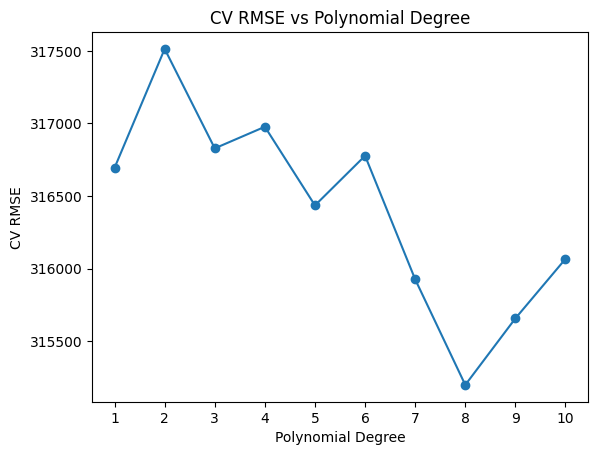

In [12]:
df.columns = df.columns.str.strip()
df['Age'] = 2024 - df['Make_Year']

from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline

cv_scores = {}

for degree in range(1, 11):
    model = make_pipeline(
        PolynomialFeatures(degree),
        LinearRegression()
    )
    scores = cross_val_score(model, df[['Age']], df['Price'],
                             cv=10, scoring='neg_mean_squared_error')
    cv_scores[degree] = np.sqrt(-scores.mean())

cv_df = pd.Series(cv_scores)
print(cv_df)
print(f"\nOptimal degree: {cv_df.idxmin()}")

cv_df.plot(marker='o')
plt.xlabel('Polynomial Degree')
plt.ylabel('CV RMSE')
plt.title('CV RMSE vs Polynomial Degree')
plt.xticks(range(1, 11))
plt.show()

**Answer:** Using 10-fold cross validation, the best polynomial degree for Age is 8, giving the lowest CV RMSE of 315,199 INR. But RMSE barely changes across degrees, showing Age alone is a weak predictor and adding complexity doesn’t improve predictions much.

4. Plot Price against Age, and then model-predicted price against Age. Does the model accurately fit the patterns in the data?

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


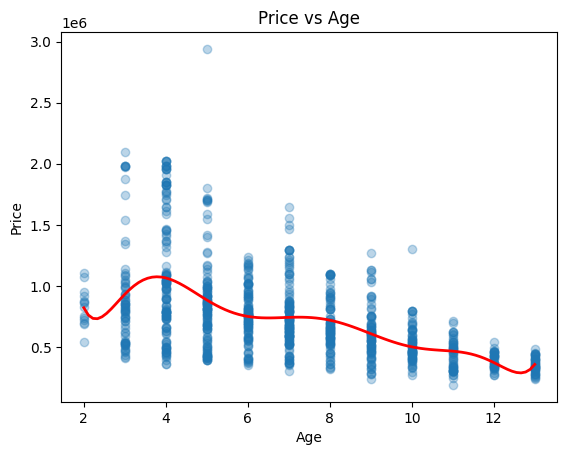

In [13]:
plt.scatter(df['Age'], df['Price'], alpha=0.3)
plt.xlabel('Age')
plt.ylabel('Price')
plt.title('Price vs Age')

best_degree = cv_df.idxmin()

model = make_pipeline(
    PolynomialFeatures(best_degree),
    LinearRegression()
)

X = df[['Age']]
y = df['Price']

model.fit(X, y)

age_grid = np.linspace(df['Age'].min(), df['Age'].max(), 100).reshape(-1, 1)
preds = model.predict(age_grid)

plt.plot(age_grid, preds, color='red', linewidth=2)
plt.show()


**Answer:** The plot shows prices generally drop with age due to depreciation, but there’s high variation at each age, so age alone is a weak predictor. The degree-8 model creates a wavy curve that overfits, indicating other variables are needed for better predictions.

Q4. This question refers to the heart_hw.csv data. It contains three variables:

* y: Whether the individual survived for three years, coded 0 for death and 1 for survival
* age: Patient's age
* transplant: labelled control for not receiving a transplant and labelled treatment for receiving a transplant

Since a heart transplant is a dangerous operation and even people who successfully get heart transplants might suffer later complications, we want to look at whether a group of transplant recipients tends to survive longer than a comparison group who does not get the procedure.

1. Compute (a) the proportion of people who survive in the control group and (b) in the treatment group. Compute (b) minus (a) as the average treatment effect (ATE). What is the ATE on three-year survival for heart transplant interventions?

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LinearRegression


df = pd.read_csv('./undergrad_ml_assignments/data/heart_hw.csv')
df.columns = df.columns.str.strip()

df['treat'] = (df['transplant'] == 'treatment').astype(int)

df.head()

,Unnamed: 0,age,transplant,y,treat
0,1,53,control,0,0
1,2,43,control,0,0
2,3,52,control,0,0
3,4,52,control,0,0
4,5,54,control,0,0


In [15]:
control_mean = df[df['treat'] == 0]['y'].mean()
treatment_mean = df[df['treat'] == 1]['y'].mean()

ATE = treatment_mean - control_mean

print("Control survival rate:", control_mean)
print("Treatment survival rate:", treatment_mean)
print("ATE:", ATE)

Control survival rate: 0.11764705882352941
Treatment survival rate: 0.34782608695652173
ATE: 0.23017902813299232


**Answer:** Survival is 11.8% in the control group and 34.8% in the treatment group. The average treatment effect is 0.23, meaning a heart transplant raises the three-year survival probability by about 23 percentage points.


2. Regress y on transplant using a linear model with a constant. Compare the intercept and transplant coefficient to the numbers you computed in part 1.

In [16]:
X = sm.add_constant(df['treat'])
model = sm.OLS(df['y'], X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.059
Model:                            OLS   Adj. R-squared:                  0.050
Method:                 Least Squares   F-statistic:                     6.354
Date:                Tue, 24 Mar 2026   Prob (F-statistic):             0.0133
Time:                        23:48:46   Log-Likelihood:                -59.591
No. Observations:                 103   AIC:                             123.2
Df Residuals:                     101   BIC:                             128.5
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.1176      0.075      1.574      0.1

**Answer:** The intercept is ~0.118, matching the control group survival rate, and the transplant coefficient is ~0.230, matching the ATE. This shows the regression mirrors the group averages, with the intercept as the control and the coefficient as the treatment effect.

3. Regress y on transplant and age. How does the coefficient on transplant change when you control for age?What do the intercept and slope represent? Plot the predicted probability of survival by age, and add a dashed horizontal line for the ATE from part 1. For what ages is the ATE over- or under-estimating the impact of a transplant?

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.147
Model:                            OLS   Adj. R-squared:                  0.130
Method:                 Least Squares   F-statistic:                     8.602
Date:                Tue, 24 Mar 2026   Prob (F-statistic):           0.000357
Time:                        23:50:01   Log-Likelihood:                -54.558
No. Observations:                 103   AIC:                             115.1
Df Residuals:                     100   BIC:                             123.0
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.7020      0.196      3.583      0.0

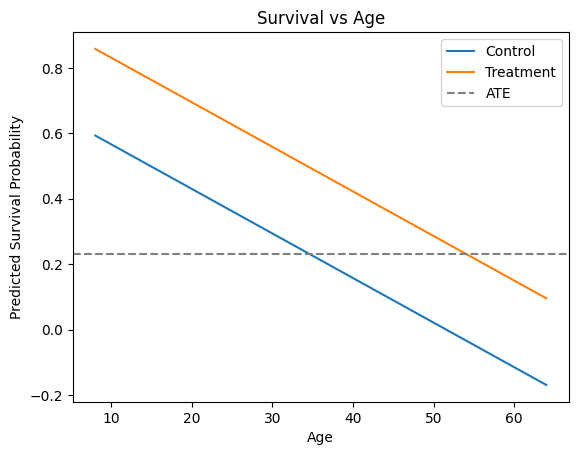

In [17]:
X = sm.add_constant(df[['treat', 'age']])
model = sm.OLS(df['y'], X).fit()
print(model.summary())

age_grid = np.linspace(df['age'].min(), df['age'].max(), 100)

pred_control_df = pd.DataFrame({
    'const': 1,
    'treat': 0,
    'age': age_grid
})
pred_control = model.predict(pred_control_df)


pred_treat_df = pd.DataFrame({
    'const': 1,
    'treat': 1,
    'age': age_grid
})
pred_treat = model.predict(pred_treat_df)

plt.plot(age_grid, pred_control, label='Control')
plt.plot(age_grid, pred_treat, label='Treatment')
plt.axhline(y=ATE, linestyle='--', color='gray', label='ATE')
plt.xlabel('Age')
plt.ylabel('Predicted Survival Probability')
plt.legend()
plt.title('Survival vs Age')
plt.show()

**Answer:** After controlling for age, the transplant effect rises to ~0.265, showing age influenced the original estimate. The intercept is survival for a control patient at age 0, and the negative age coefficient shows survival drops with age. The gap between groups is fairly constant, but the ATE overestimates for younger and underestimates for older patients, so the effect varies by age.

4. Now, include transplant, age, and transplant * age as controls. Repeat your analysis from part 3. How does allowing age and transplant to interact change your predictions? What pattern do you notice?

In [18]:
df['interaction'] = df['treat'] * df['age']

X = sm.add_constant(df[['treat', 'age', 'interaction']])
model = sm.OLS(df['y'], X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.172
Model:                            OLS   Adj. R-squared:                  0.147
Method:                 Least Squares   F-statistic:                     6.839
Date:                Tue, 24 Mar 2026   Prob (F-statistic):           0.000310
Time:                        23:53:09   Log-Likelihood:                -53.033
No. Observations:                 103   AIC:                             114.1
Df Residuals:                      99   BIC:                             124.6
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
const           0.3549      0.280      1.269      

**Answer:** Adding an interaction between transplant and age lets the treatment effect change with age. The model shows transplant benefits decline as patients get older, so younger patients gain more, and the gap between groups narrows with age for a more realistic view.

5. Use 10-fold cross validation to evaluate the predictive accuracy of these models.

In [19]:
X1 = df[['treat']]

X2 = df[['treat', 'age']]

X3 = df[['treat', 'age', 'interaction']]

y = df['y']

model = LinearRegression()

cv1 = -cross_val_score(model, X1, y, cv=10, scoring='neg_mean_squared_error').mean()
cv2 = -cross_val_score(model, X2, y, cv=10, scoring='neg_mean_squared_error').mean()
cv3 = -cross_val_score(model, X3, y, cv=10, scoring='neg_mean_squared_error').mean()

print("Model 1 (treat):", cv1)
print("Model 2 (treat + age):", cv2)
print("Model 3 (interaction):", cv3)

Model 1 (treat): 0.20970277289824915
Model 2 (treat + age): 0.19922806049232317
Model 3 (interaction): 0.19609811380122735


**Answer:** The transplant-only model has the highest error, adding age lowers it, and the interaction model has the lowest error. This shows including age and the interaction captures more information and predicts survival best.

6. Imagine this model is used to prioritize transplant access. What are your concerns about model construction and deployment?

**Answer:** A key issue is that the model may be biased if the data isn’t representative, potentially leading to unfair transplant decisions. It could disadvantage older or high-risk patients by reducing survival to a single prediction, and it overlooks important medical factors, so using it alone could result in poor or unethical choices.